In [1]:
import torch
import numpy as np
import random
from torch.utils.data import DataLoader, Dataset
from torch_geometric.datasets import Planetoid, Amazon, KarateClub
from ogb.linkproppred import PygLinkPropPredDataset
from torch_geometric.utils import negative_sampling, add_self_loops, train_test_split_edges, k_hop_subgraph
from torch_geometric.transforms import RandomLinkSplit
from tqdm import tqdm
import argparse 
from ast import literal_eval
import code
import torch_geometric
import os
from torch_sparse.tensor import SparseTensor
from itertools import combinations
from tqdm import tqdm
import scipy.sparse as ssp
import datetime

import time


def create_timestamp_folder(directory, dataset):
    # Get the current date and time
    current_time = datetime.datetime.now()
    timestamp = current_time.strftime("%Y-%m-%d_%H-%M")

    # Create the folder name with the timestamp
    folder_name = os.path.join(directory, timestamp + f'_{dataset}')

    # Create the folder
    try:
        os.makedirs(folder_name)
        print(f"Folder '{folder_name}' created successfully.")
    except OSError as e:
        print(f"Error creating folder: {e}")

    return folder_name


def compute_edges(split_edge, heart=False):
    """
    Compute the train, valid, and test edges based on edge split.

    :param split_edge: edge split.
    :return: train_edges_pos, train_edges_neg, valid_edges, valid_true, test_edges, test_true
    """

    # Train edges.
    train_edges_pos = split_edge['train']['edge']
    train_edges_pos = train_edges_pos[train_edges_pos[:, 0] < train_edges_pos[:, 1]]  # Only include upper triangle.
    train_edges_neg = split_edge['train']['edge_neg']

    # code.interact(local=locals())
    # Valid edges.
    valid_edges = torch.vstack([split_edge['valid']['edge'], split_edge['valid']['edge_neg']])
    valid_true = torch.cat([torch.ones(split_edge['valid']['edge'].shape[0], dtype=int), torch.zeros(split_edge['valid']['edge_neg'].shape[0], dtype=int)])

    if not heart:
        index = torch.randperm(valid_edges.shape[0])  # Shuffle edges for expected values of precision@k for ties.
        valid_edges = valid_edges[index]
        valid_true = valid_true[index]

    # Test edges.
    test_edges = torch.vstack([split_edge['test']['edge'], split_edge['test']['edge_neg']])
    test_true = torch.cat([torch.ones(split_edge['test']['edge'].shape[0], dtype=int), torch.zeros(split_edge['test']['edge_neg'].shape[0], dtype=int)])

    if not heart:
        index = torch.randperm(test_edges.shape[0])
        test_edges = test_edges[index]
        test_true = test_true[index]

    return train_edges_pos, train_edges_neg, valid_edges, valid_true, test_edges, test_true


def set_random_seed(random_seed):
    """
    Set the random seed.
    :param random_seed: Seed to be set.
    """
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    random.seed(random_seed)


def split_dataset(data, valid_ratio=0.05, test_ratio=0.1, random_seed=0, heart_splits=None):
    """
    Split the edges/nonedges for biased training, full training, (full) validation and (full) testing.

    :param data: PyG dataset data.
    :param valid_ratio: ratio of validation edges.
    :param test_ratio: ratio of test edges.
    :param random_seed: random seed for the split.
    :return: edge splits
    """
    
    set_random_seed(random_seed)
    n = data.num_nodes

    if heart_splits:
        from types import SimpleNamespace
        split_data = SimpleNamespace(train_pos_edge_index=heart_splits['train']['edge'].t(), val_pos_edge_index=heart_splits['valid']['edge'].t(), test_pos_edge_index=heart_splits['test']['edge'].t(), num_nodes=n)

    else:
        split_data = train_test_split_edges(data, valid_ratio, test_ratio)


    split_edge = {'biased_train': {}, 'valid': {}, 'test': {}, 'train': {}}

    # Biased training with negative sampling.
    split_edge['biased_train']['edge'] = split_data.train_pos_edge_index.t()
    edge_index, _ = add_self_loops(split_data.train_pos_edge_index)  # To avoid negative sampling of self loops.
    split_data.train_neg_edge_index = negative_sampling(
        edge_index, num_nodes=split_data.num_nodes,
        num_neg_samples=split_data.train_pos_edge_index.size(1))
    split_edge['biased_train']['edge_neg'] = split_data.train_neg_edge_index.t()

    # Full training with all negative pairs in the training graph (including validation and testing positive edges).
    split_edge['train']['edge'] = split_data.train_pos_edge_index.t()
    train_edge_neg_mask = torch.ones((n, n), dtype=bool)
    train_edge_neg_mask[tuple(split_edge['train']['edge'].t().tolist())] = False
    train_edge_neg_mask = torch.triu(train_edge_neg_mask, 1)
    split_edge['train']['edge_neg'] = torch.nonzero(train_edge_neg_mask)

    # Full validation with all negative pairs in the training graph (including testing positive edges, excluding validation positive edges).
    split_edge['valid']['edge'] = split_data.val_pos_edge_index.t()
    valid_edge_neg_mask = train_edge_neg_mask.clone()
    valid_edge_neg_mask[tuple(split_edge['valid']['edge'].t().tolist())] = False
    split_edge['valid']['edge_neg'] = torch.nonzero(valid_edge_neg_mask)

    # Full testing with all negative pairs in the training graph (excluding validation and testing positive edges).
    split_edge['test']['edge'] = split_data.test_pos_edge_index.t()
    test_edge_neg_mask = valid_edge_neg_mask.clone()
    test_edge_neg_mask[tuple(split_edge['test']['edge'].t().tolist())] = False
    split_edge['test']['edge_neg'] = torch.nonzero(test_edge_neg_mask)


    

    return split_edge



def split_dataset_partition_sampling(data, n_partitions=3, valid_ratio=0.05, test_ratio=0.1, random_seed=0, heart_splits=None):
    """
    Split the edges/nonedges for Cluster-importance sampling.
    As described in the paper, the idea is to sample negative pairs
    from within graph partitions.

    :param data: PyG dataset data.
    :param valid_ratio: ratio of validation edges.
    :param test_ratio: ratio of test edges.
    :param random_seed: random seed for the split.
    :return: edge splits
    """

    set_random_seed(random_seed)

    adj = SparseTensor.from_edge_index(data.edge_index, edge_attr=torch.ones(size=(data.edge_index.shape[1],)))
        
    partitions, part_idx, part_nodes = adj.partition(n_partitions)

    # partitions, part_idx, part_nodes = torch.load("./7000_partitions_vessel.pth")

    neg_edge_index = None

    for part_start, part_end in tqdm(list(zip(part_idx, part_idx[1:-1]))):
        cur_partition_nodes = part_nodes[part_start:part_end + 1].tolist()

        all_possible_pairs = torch.tensor(list(combinations(cur_partition_nodes, 2)))

        if neg_edge_index is None:
            neg_edge_index = all_possible_pairs
        else:
            neg_edge_index = torch.cat([neg_edge_index, all_possible_pairs])

    
    neg_edge_index = neg_edge_index.t()

    set_random_seed(random_seed)
    n = data.num_nodes

    if heart_splits:
        from types import SimpleNamespace
        train_data = SimpleNamespace(edge_label_index=heart_splits['train']['edge'].t())
        val_data = SimpleNamespace(edge_label_index=heart_splits['valid']['edge'].t()) 
        test_data = SimpleNamespace(edge_label_index=heart_splits['test']['edge'].t())

    else:
        transform = RandomLinkSplit(add_negative_train_samples=False, num_val=valid_ratio, num_test=test_ratio)
        train_data, val_data, test_data = transform(data)

    # code.interact(local=locals())

    # split_data = train_test_split_edges(data, valid_ratio, test_ratio)
    split_edge = {'biased_train': {}, 'valid': {}, 'test': {}, 'train': {}}

    # Full training with all negative pairs in the training graph (including validation and testing positive edges).
    split_edge['train']['edge'] = train_data.edge_label_index.t()
    all_edges_train = torch.cat([data.edge_index, train_data.edge_label_index], dim=1)
    train_edge_label_mask = SparseTensor.from_edge_index(all_edges_train, torch.full(size=(all_edges_train.shape[1],), fill_value=-1), adj.sizes()).coalesce(reduce='max')
    neg_edge_index_mask_train = SparseTensor.from_edge_index(neg_edge_index, torch.ones(size=(neg_edge_index.shape[1],)), adj.sizes())
    row, col, mask = (neg_edge_index_mask_train + train_edge_label_mask).coo()
    split_edge['train']['edge_neg'] = torch.vstack([row[mask == 1], col[mask == 1]]).t()


    # Full validation with all negative pairs in the training graph (including testing positive edges, excluding validation positive edges).
    split_edge['valid']['edge'] = val_data.edge_label_index.t()
    all_edges_val = torch.cat([data.edge_index, train_data.edge_label_index, val_data.edge_label_index], dim=1)
    val_edge_label_mask = SparseTensor.from_edge_index(all_edges_val, torch.full(size=(all_edges_val.shape[1],), fill_value=-1), adj.sizes()).coalesce(reduce='max')
    neg_edge_index_mask_val = SparseTensor.from_edge_index(neg_edge_index, torch.ones(size=(neg_edge_index.shape[1],)), adj.sizes())
    row, col, mask = (neg_edge_index_mask_val + val_edge_label_mask).coo()
    split_edge['valid']['edge_neg'] = torch.vstack([row[mask == 1], col[mask == 1]]).t()


    # Full testing with all negative pairs in the training graph (excluding validation and testing positive edges).
    split_edge['test']['edge'] = test_data.edge_label_index.t()
    all_edges_test = torch.cat([data.edge_index, train_data.edge_label_index, val_data.edge_label_index, test_data.edge_label_index], dim=1)
    test_edge_label_mask = SparseTensor.from_edge_index(all_edges_test, torch.full(size=(all_edges_test.shape[1],), fill_value=-1), adj.sizes()).coalesce(reduce='max')
    neg_edge_index_mask_test = SparseTensor.from_edge_index(neg_edge_index, torch.ones(size=(neg_edge_index.shape[1],)), adj.sizes())
    
    del row, col, mask, neg_edge_index_mask_val, val_edge_label_mask, all_edges_val, neg_edge_index_mask_train
    # import code
    # code.interact(local=locals())
    row, col, mask = (neg_edge_index_mask_test + test_edge_label_mask).coo()
    split_edge['test']['edge_neg'] = torch.vstack([row[mask == 1], col[mask == 1]]).t()

    print(">>>> finished sampling neg samples")
    # code.interact(local=locals())

    return split_edge



# def (dataset:str, heart_files_path:str=''):

#     assert os.path.exists(heart_files_path), f"'{heart_files_path}' -- Path to files does not exist, please check"



#     val_neg_samples = torch.from_numpy(np.load(os.path.join(heart_files_path, 'heart_valid_samples.npy')))
#     test_neg_samples = torch.from_numpy(np.load(os.path.join(heart_files_path, 'heart_test_samples.npy')))

#     if ('ogbl' not in dataset):



def heart_read_data(data, data_name, dir_path, filename, partitions=None):

    print(">>> Reading HeaRT splits...")

    data_name = data_name

    node_set = set()
    train_pos, valid_pos, test_pos = [], [], []
    train_neg, valid_neg, test_neg = [], [], []

    for split in ['train', 'test', 'valid']:

        
        path = dir_path+ '/{}/{}_pos.txt'.format(data_name, split)
      
        for line in open(path, 'r'):
            sub, obj = line.strip().split('\t')
            sub, obj = int(sub), int(obj)
            
            node_set.add(sub)
            node_set.add(obj)
            
            if sub == obj:
                continue

            if split == 'train': 
                train_pos.append((sub, obj))
                

            if split == 'valid': valid_pos.append((sub, obj))  
            if split == 'test': test_pos.append((sub, obj))
    
    num_nodes = len(node_set)
    print('the number of nodes in ' + data_name + ' is: ', num_nodes)

    

    train_edge = torch.transpose(torch.tensor(train_pos), 1, 0)
    edge_index = torch.cat((train_edge,  train_edge[[1,0]]), dim=1)
    edge_weight = torch.ones(edge_index.size(1))

    with open(f'{dir_path}/{data_name}/heart_valid_{filename}', "rb") as f:
        valid_neg = np.load(f)
        valid_neg = torch.from_numpy(valid_neg)
    with open(f'{dir_path}/{data_name}/heart_test_{filename}', "rb") as f:
        test_neg = np.load(f)
        test_neg = torch.from_numpy(test_neg)


    A = ssp.csr_matrix((edge_weight.view(-1), (edge_index[0], edge_index[1])), shape=(num_nodes, num_nodes)) 

    adj = SparseTensor.from_edge_index(edge_index, edge_weight, [num_nodes, num_nodes])
          

    train_pos_tensor = torch.tensor(train_pos)

    valid_pos = torch.tensor(valid_pos)
    
    test_pos =  torch.tensor(test_pos)
    

    idx = torch.randperm(train_pos_tensor.size(0))
    idx = idx[:valid_pos.size(0)]
    train_val = train_pos_tensor[idx]


    feature_embeddings = torch.load(dir_path+ '/{}/{}'.format(data_name, 'gnn_feature'))
    feature_embeddings = feature_embeddings['entity_embedding']

    splits = {}
    splits['train'] = dict()
    splits['valid'] = dict()
    splits['test'] = dict()
    # splits['adj'] = adj
    splits['train']['edge'] = train_pos_tensor
    splits['train']['train_val'] = train_val

    splits['valid']['edge'] = valid_pos
    splits['valid']['edge_neg'] = valid_neg
    splits['test']['edge'] = test_pos
    splits['test']['edge_neg'] = test_neg

    # code.interact(local=locals())

    # We will use the full training negative samples
    # to train the model, that's why we are re-using the "split_dataset()"
    # function.
    if partitions > 1:
        print(">>> Sampling negative pairs from partition sampling...")
        splits_partition_sampling_full_training = split_dataset_partition_sampling(data, heart_splits=splits, n_partitions=partitions)
        splits['train']['edge_neg'] = splits_partition_sampling_full_training['train']['edge_neg']
        print(">>> ...ok")

    else:
        print(">>> Sampling negative pairs from full training...")
        splits_full_training = split_dataset(data=data, heart_splits=splits)
        splits['train']['edge_neg'] = splits_full_training['train']['edge_neg']
        print(">>> ...ok")


    return splits
        


def split_dataset_ogbl(data, valid_ratio=0.05, test_ratio=0.1, random_seed=0):
    """
    Split the edges/nonedges for biased training, full training, (full) validation and (full) testing.

    :param data: PyG dataset data.
    :param valid_ratio: ratio of validation edges.
    :param test_ratio: ratio of test edges.
    :param random_seed: random seed for the split.
    :return: edge splits
    """

    set_random_seed(random_seed)

    n = data.num_nodes
    transform = RandomLinkSplit()
    train_data, val_data, test_data = transform(data)

    # split_data = train_test_split_edges(data, valid_ratio, test_ratio)
    split_edge = {'biased_train': {}, 'valid': {}, 'test': {}, 'train': {}}

    # Biased training with negative sampling.
    train_label_index = train_data.edge_label.bool()
    split_edge['biased_train']['edge'] = train_data.edge_label_index[:, train_label_index].t()
    split_edge['biased_train']['edge_neg'] = train_data.edge_label_index[:, ~train_label_index].t()

    # Full training with all negative pairs in the training graph (including validation and testing positive edges).
    split_edge['train']['edge'] = train_data.edge_label_index[:, train_label_index].t()
    # train_edge_neg_mask = torch.ones((n, n), dtype=bool)
    # train_edge_neg_mask[tuple(split_edge['train']['edge'].t().tolist())] = False
    # train_edge_neg_mask = torch.triu(train_edge_neg_mask, 1)
    # split_edge['train']['edge_neg'] = torch.tensor([[], []]).t()
    split_edge['train']['edge_neg'] = train_data.edge_label_index[:, ~train_label_index].t()

    # Full validation with all negative pairs in the training graph (including testing positive edges, excluding validation positive edges).
    val_label_index = val_data.edge_label.bool()
    split_edge['valid']['edge'] = val_data.edge_label_index[:, val_label_index].t()
    # valid_edge_neg_mask = train_edge_neg_mask.clone()
    # valid_edge_neg_mask[tuple(split_edge['valid']['edge'].t().tolist())] = False
    # split_edge['valid']['edge_neg'] = torch.tensor([[], []]).t()
    split_edge['valid']['edge_neg'] = val_data.edge_label_index[:, ~val_label_index].t()

    # Full testing with all negative pairs in the training graph (excluding validation and testing positive edges).
    test_label_index = test_data.edge_label.bool()
    split_edge['test']['edge'] = test_data.edge_label_index[:, test_label_index].t()
    # test_edge_neg_mask = valid_edge_neg_mask.clone()
    # test_edge_neg_mask[tuple(split_edge['test']['edge'].t().tolist())] = False
    split_edge['test']['edge_neg'] = test_data.edge_label_index[:, ~test_label_index].t()

    return split_edge



def remove_intercluster(pairs, node_to_partition):
    '''
    Given a list of edges (pairs) in the PyG format and a partition mapper dictionary
    (node_to_partition), removes from the list of pairs the ones that contain nodes
    from different graph partitions
    '''
    

    # Checks, for every pair, if both nodes are in the same
    # partition. If so, then they are possible collisions between
    # the pairs sampled in the clusters and the original validation
    # and test, so we will maintain these pairs.
    maintain_edge = []
    for pair in tqdm(pairs.t(), 'Finding pairs intercluster'):
        i, j = int(pair[0]), int(pair[1])

        i_partition = node_to_partition[i]['node_partition_idx']
        j_partition = node_to_partition[j]['node_partition_idx']

        intracluster = (i_partition == j_partition)

        maintain_edge.append(i_partition if intracluster else -1)
    
    maintain_edge = torch.tensor(maintain_edge)

    # print(f"{sum(maintain_edge != -1)} intraclusters pairs were found...")

    return pairs[:, maintain_edge != -1], maintain_edge



def _remove_intercluster(pairs, node_to_partition):
    '''
    Given a list of edges (pairs) in the PyG format and a partition mapper dictionary
    (node_to_partition), removes from the list of pairs the ones that contain nodes
    from different graph partitions
    '''
    

    # Checks, for every pair, if both nodes are in the same
    # partition. If so, then they are possible collisions between
    # the pairs sampled in the clusters and the original validation
    # and test, so we will maintain these pairs.
    maintain_edge = []
    for pair in tqdm(pairs.t(), 'Finding pairs intercluster'):
        i, j = int(pair[0]), int(pair[1])

        i_partition = node_to_partition[i]['node_partition_idx']
        j_partition = node_to_partition[j]['node_partition_idx']

        intracluster = (i_partition == j_partition)

        maintain_edge.append(i_partition if intracluster else -1)
    
    maintain_edge = torch.tensor(maintain_edge)

    # print(f"{sum(maintain_edge != -1)} intraclusters pairs were found...")

    return pairs[:, maintain_edge != -1], maintain_edge



def remove_dataleak(intracluster_pairs, node_to_partition, splits):
    '''
    Given a list of intracluster_pairs, checks if any of the pairs
    is present in the training pairs contained in 'splits'.

    If a given splits ends up having more positive than negative pairs,
    this function will also rebalance this.
    '''

    for pair in tqdm(intracluster_pairs.t(), desc="Removing dataleaks"):
        i, j = int(pair[0]), int(pair[1])

        partition = node_to_partition[i]['node_partition_idx']

        i_partition = node_to_partition[i]['node_idx']
        j_partition = node_to_partition[j]['node_idx']

        train_edges_neg = splits[partition]['train_edges_neg']

        mask = torch.all(train_edges_neg.t() == torch.tensor([i_partition, j_partition]), dim=1)
        mask += torch.all(train_edges_neg.t() == torch.tensor([j_partition, i_partition]), dim=1)

        mask = ~mask

        splits[partition]['train_edges_neg'] = train_edges_neg[:, mask]


    # Balancing the number of positive pairs
    # in comparisson to the number of negative pairs
    # per split.
    for partition in splits.keys():
        num_neg_pairs = splits[partition]['train_edges_neg'].shape[1]
        num_pos_pairs = splits[partition]['train_edges_pos'].shape[1]

        if (num_pos_pairs > num_neg_pairs):
            splits[partition]['train_edges_pos'] = splits[partition]['train_edges_pos'][:, :num_neg_pairs]

    return splits



def extract_cluster_edge_index(pair, node_to_partition, partition):

    i, j = int(pair[0]), int(pair[1])

    i_partition = node_to_partition[i]['node_partition_idx']
    j_partition = node_to_partition[j]['node_partition_idx']
    
    return (i_partition == partition) and (j_partition == partition)


def extract_cluster_edge_index_for(pairs, node_to_partition):

    converted_pairs = [(node_to_partition[int(pair[0])]['node_idx'], node_to_partition[int(pair[1])]['node_idx']) for pair in pairs.t().tolist()]
        
    return torch.tensor(converted_pairs).t()



def convert_to_partition_index(pairs, node_to_partition):

    converted_pairs = [(node_to_partition[int(pair[0])]['node_idx'], node_to_partition[int(pair[1])]['node_idx']) for pair in pairs.t().tolist()]
        
    return torch.tensor(converted_pairs).t()



def graph_splits(graph_partitions, train_graph, val_graph, test_graph, full_training=True, save_dir=None, ogbl=False):
    '''
    Given the train, validation and test graphs, along with the graph partitions, this function
    organizes our training data in different splits, one per graph partition and removes possible leaks between
    training, validation and test due to the sampling procedure done per partition.
    
    :param graph_partitions: ClusterData object of the graph partitioned.
    :param train_graph: torch_geometric.data.Data object with the training graph as the edge index.
    :param val_graph: torch_geometric.data.Data object with the validation pairs.
    :param test_graph: torch_geometric.data.Data object with the test pairs.
    :param full_training: generates splits using full training (True) or biased training (False).
    :param save_dir: path in which we will cache the splits.
    :param ogbl: in case we are using full-training in ogbl datasets, it samples validation and test negative pairs only within each cluster.
    
    :return: splits, intercluster_splits, node_to_partition
    '''

    n_partitions = len(graph_partitions)

    # If we have cached data, then we will just read it
    if save_dir and os.path.isfile(save_dir + f'splits_{n_partitions}.pt'):
        splits = torch.load(save_dir + f'splits_{n_partitions}.pt')
        intercluster_splits = torch.load(save_dir + f'intercluster_splits_{n_partitions}.pt')
        node_to_partition = torch.load(save_dir + f'node_to_partition_{n_partitions}.pt')

        return splits, intercluster_splits, node_to_partition


    # Stores partition metadata regarding each node of the network.
    node_to_partition = {}
    partition_idx = 0
    node_partition_idx = 0
    for idx, node in enumerate(graph_partitions.perm):
        if idx >= graph_partitions.partptr[partition_idx + 1]:
            partition_idx += 1
            node_partition_idx = 0

        node_to_partition[int(node)] = dict()
        node_to_partition[int(node)]['node_partition_idx'] = partition_idx # In which partition this node is located
        node_to_partition[int(node)]['node_idx'] = node_partition_idx # What is its index in the partition it is located

        node_partition_idx += 1
    
    splits = dict()


    valid_edge_index = val_graph.edge_index
    test_edge_index = test_graph.edge_index

    valid_edges = val_graph.edge_label_index
    valid_true = val_graph.edge_label

    test_edges = test_graph.edge_label_index
    test_true = test_graph.edge_label

    intercluster_mask_val = torch.zeros((val_graph.edge_label_index.shape[1])).bool()
    intercluster_mask_test = torch.zeros((test_graph.edge_label_index.shape[1])).bool()

    intracluster_pairs_val, intracluster_idx_val = remove_intercluster(val_graph.edge_label_index, node_to_partition=node_to_partition)
    intracluster_pairs_test, intracluster_idx_test = remove_intercluster(test_graph.edge_label_index, node_to_partition=node_to_partition)

    intercluster_mask_val = (intracluster_idx_val == - 1)
    intercluster_mask_test = (intracluster_idx_test == -1) 
    
    _, intracluster_edge_idx_val = remove_intercluster(val_graph.edge_index, node_to_partition=node_to_partition)
    _, intracluster_edge_idx_test = remove_intercluster(test_graph.edge_index, node_to_partition=node_to_partition)

    
    for idx, partition in tqdm(enumerate(graph_partitions), desc="Processing graph partitions"):

        subgraph = partition

        train_edge_index = subgraph.edge_index

        splits[idx] = dict()

        splits[idx]['subgraph'] = subgraph

        splits[idx]['train_edge_index'] = train_edge_index


        del subgraph.edge_label, subgraph.edge_label_index

        
        # Resampling subgraph pairs.
        # The idea here is to take advantage of the fact that we have
        # a subgraph computed using METIS to sample more informative pairs
        # than the ones contained in the original training set.
        transform = RandomLinkSplit(is_undirected=False, num_val=0.0, num_test=0.0)
        subgraph_train, subgraph_val, subgraph_test = transform(subgraph)


        num_pos_edges = subgraph_train.edge_label.bool().sum()
        num_neg_edges = (~subgraph_train.edge_label.bool()).sum()

        train_edges_pos = subgraph_train.edge_label_index[:, subgraph_train.edge_label.bool()]

        if full_training:
            n = subgraph.num_nodes
            # code.interact(local=locals())
            train_edge_neg_mask = torch.ones((n, n), dtype=bool)
            train_edge_neg_mask[tuple(train_edges_pos.tolist())] = False
            train_edge_neg_mask = torch.triu(train_edge_neg_mask, 1)
            train_edges_neg = torch.nonzero(train_edge_neg_mask).t()

            if (ogbl):

                subgraph_val_edges_pos = subgraph_val.edge_label_index[:, subgraph_val.edge_label.bool()]
                subgraph_test_edges_pos = subgraph_test.edge_label_index[:, subgraph_test.edge_label.bool()]
                
                valid_edge_neg_mask = train_edge_neg_mask.clone()
                valid_edge_neg_mask[tuple(subgraph_val_edges_pos.tolist())] = False
                valid_edges_neg = torch.nonzero(valid_edge_neg_mask).t()

                # Full testing with all negative pairs in the training graph (excluding validation and testing positive edges).
                test_edge_neg_mask = valid_edge_neg_mask.clone()
                test_edge_neg_mask[tuple(subgraph_test_edges_pos.tolist())] = False
                test_edges_neg = torch.nonzero(test_edge_neg_mask).t()

        else:
            train_edges_neg = subgraph_train.edge_label_index[:, ~subgraph_train.edge_label.bool()] 


        splits[idx]['train_edges_pos'] = train_edges_pos
        splits[idx]['train_edges_neg'] = train_edges_neg
        

        
        cluster_mask_val = (intracluster_idx_val == idx)
        cluster_mask_test = (intracluster_idx_test == idx)

        if (ogbl):

            valid_edges_pos = convert_to_partition_index(valid_edges[:, cluster_mask_val], node_to_partition)

            test_edges_pos = convert_to_partition_index(test_edges[:, cluster_mask_test], node_to_partition)

            splits[idx]['valid_edges'] = torch.cat([valid_edges_pos, valid_edges_neg], dim=1)
            splits[idx]['valid_true'] = torch.cat([torch.ones(valid_edges_pos.shape[1]), torch.zeros(valid_edges_neg.shape[1])])

            splits[idx]['test_edges'] = torch.cat([test_edges_pos, test_edges_neg], dim=1)
            splits[idx]['test_true'] = torch.cat([torch.ones(test_edges_pos.shape[1]), torch.zeros(test_edges_neg.shape[1])])

            splits[idx]['valid_edge_index'] = subgraph_val.edge_index
            
            splits[idx]['test_edge_index'] = subgraph_test.edge_index

        else:
            # Selecting the validation edges contained in the cluster 'idx'
            splits[idx]['valid_edges'] = convert_to_partition_index(valid_edges[:, cluster_mask_val], node_to_partition)
            splits[idx]['valid_true'] = valid_true[cluster_mask_val]

            # Selecting the validation edges contained in the cluster 'idx'
            splits[idx]['test_edges'] = convert_to_partition_index(test_edges[:, cluster_mask_test], node_to_partition)
            splits[idx]['test_true'] = test_true[cluster_mask_test]


            cluster_edge_idx_mask_val = (intracluster_edge_idx_val == idx)
            cluster_edge_idx_mask_test = (intracluster_edge_idx_test == idx)

            splits[idx]['valid_edge_index'] = convert_to_partition_index(valid_edge_index[:, cluster_edge_idx_mask_val], node_to_partition)

            splits[idx]['test_edge_index'] = convert_to_partition_index(test_edge_index[:, cluster_edge_idx_mask_test], node_to_partition)


    # Accounting for the intercluster pairs left behind
    intercluster_splits = dict()
    
    intercluster_splits['valid_edges'] = valid_edges[:, intercluster_mask_val]
    intercluster_splits['valid_true'] = valid_true[intercluster_mask_val]

    intercluster_splits['test_edges'] = test_edges[:, intercluster_mask_test]
    intercluster_splits['test_true'] = test_true[intercluster_mask_test]


    torch.save(splits, save_dir + f'splits_{n_partitions}.pt')
    torch.save(intercluster_splits, save_dir + f'intercluster_splits_{n_partitions}.pt')
    torch.save(node_to_partition, save_dir + f'node_to_partition_{n_partitions}.pt')

    return splits, intercluster_splits, node_to_partition


def compute_batch_stats(out, running_sum, running_sum_squared, running_n):
    results = out.detach().clone()
    running_sum += results.sum()
    running_sum_squared += torch.dot(results, results)
    running_n += len(results)
    
    running_mean = running_sum / running_n
    
    running_std = torch.sqrt(running_sum_squared / (running_n - 1)) - (running_mean ** 2)

    # mean = min(out_flatten[valid_idx])
    # std = max(out_flatten[valid_idx]) - min(out_flatten[valid_idx])
    return running_mean, running_std, running_sum, running_sum_squared, running_n


def parse_args():
    """
    Parse the arguments.

    :return: Parsed arguments
    """

    parser = argparse.ArgumentParser(description="Training")

    parser.add_argument('--dataset', default='Cora',
                        help='Dataset. Default is Cora. ')
    parser.add_argument('--eta', type=float, default=0.5,
                        help='Proportion of added edges. Default is 0.0. ')
    parser.add_argument('--alpha', type=float, default=0.5,
                        help='Topological weight. Default is 0.0. ')
    parser.add_argument('--beta', type=float, default=0.25,
                        help='Trained weight. Default is 1.0. ')
    parser.add_argument('--add-self-loop', type=literal_eval, default=True,
                        help='Whether to add self-loops to all nodes. Default is False. ')
    parser.add_argument('--trained-edge-weight-batch-size', type=int, default=50000,
                        help='Batch size for computing the trained edge weights. Default is 20000. ')
    parser.add_argument('--graph-learning-type', default='mlp',
                        help='Type of the graph learning component. Default is mlp. ')
    parser.add_argument('--num-layers', type=int, default=3,
                        help='Number of layers in mlp. Default is 3. ')
    parser.add_argument('--hidden-channels', type=int, default=128,
                        help='Number of hidden channels in mlp. Default is 128. ')
    parser.add_argument('--dropout', type=float, default=0.5,
                        help='Dropout rate. Default is 0.5. ')
    parser.add_argument('--topological-heuristic-type', default='ac',
                        help='Type of the topological heuristic component. Default is ac. ')
    parser.add_argument('--scaling-parameter', type=int, default=3,
                        help='Scaling parameter of ac. Default is 3. ')
    parser.add_argument('--lr', type=float, default=0.001,
                        help='Learning rate. Default is 0.001. ')
    parser.add_argument('--epochs', type=int, default=250,
                        help='Number of epochs. Default is 250. ')
    parser.add_argument('--runs', type=int, default=3,
                        help='Number of runs. Default is 3. ')
    parser.add_argument('--train-batch-ratio', type=float, default=0.01,
                        help='Ratio of training edges per train batch. Default is 0.01. ')
    parser.add_argument('--val-batch-ratio', type=float, default=0.01,
                        help='Ratio of val edges per train batch. Default is 0.01. ')
    parser.add_argument('--sample-ratio', type=float, default=0.1,
                        help='Ratio of training edges per train batch. Default is 0.01. ')
    parser.add_argument('--random-seed', type=int, default=0,
                        help='Random seed for training. Default is 1. ')
    parser.add_argument('--cuda', type=int, default=0,
                        help='Index of cuda device to use. Default is 0. ')
    parser.add_argument('--num-partitions', type=int, default=1)
    parser.add_argument('--partition-eval', action='store_true')
    parser.add_argument('--sparse-s', type=literal_eval, default=False)
    parser.add_argument('--full-training', action='store_true')
    parser.add_argument('--no-wandb', action='store_true')
    parser.add_argument('--intracluster-only', action='store_true')
    parser.add_argument('--no-batch', action='store_true')
    parser.add_argument('--heart-path', type=str, default='')
    
    return parser.parse_args()


def load_dataset(dataset):
    """
    Load the dataset from PyG.
    :param dataset: name of the dataset. Options: 'Karate'
    :return: PyG dataset data.
    """
    data_folder = f'data/{dataset}/'
    if dataset in ('Karate'):
        pyg_dataset = KarateClub(data_folder)
    elif dataset in ('Cora', 'CiteSeer', 'PubMed'):
        pyg_dataset = Planetoid(data_folder, dataset)
    elif dataset in ('Photo', 'Computers'):
        pyg_dataset = Amazon(data_folder, dataset)
    elif dataset in ('ogbl-ppa'):
        pyg_dataset = PygLinkPropPredDataset('ogbl-ppa', root=data_folder)
    elif dataset in ('ogbl-ddi', 'ogbl-collab', 'ogbl-ppa', 'ogbl-wikikg2', 'ogbl-vessel', 'ogbl-biokg'):
        pyg_dataset = PygLinkPropPredDataset(dataset, root=data_folder)
    else:
        raise NotImplementedError(f'{dataset} not supported. ')
    data = pyg_dataset.data
    
    return data, pyg_dataset


@torch.jit.script
def cosine_sim(x:torch.Tensor, y:torch.Tensor) -> torch.Tensor:
    return (y @ x.t()) / torch.outer(y.norm(p=2, dim=1), x.norm(p=2, dim=1))



def compute_batches(rows, batch_size, shuffle=True):
    """
    Compute the batches of rows. This implementation is much faster than pytorch's dataloader.
    :param rows: rows to split into batches.
    :param batch_size: size of each batch.
    :param shuffle: whether to shuffle the rows before splitting.
    :return:
    """

    if shuffle:
        return torch.split(rows[torch.randperm(rows.shape[0])], batch_size)
    else:
        return torch.split(rows, batch_size)


def compute_matrices(edges, edges_pos, edge_neighbors, A, training):
    
    # Finding the biggest dfs in the batch.
    # This will be the size of the matrix we'll  consider
    size = 0
    for edge in edges:
        i, j = int(edge[0]), int(edge[1])
        if ((i, j) in edge_neighbors and len(edge_neighbors[(i, j)]) > size):
                size = len(edge_neighbors[(i, j)])


    for idx, edge in enumerate(edges):
        i, j = int(edge[0]), int(edge[1])

        A_tilde = A.index_put(tuple(edges_pos.t()), torch.zeros(
                    edges_pos.shape[0], device=A.device)) if training else A

        neighbors = edge_neighbors[(i, j)]

        # Hash creation step.
        # This will be used to reduce the size of all tensors used in the computation of the autocovatiance
        neighborhood_idx = dict(zip(neighbors, range(0, len(neighbors))))
        edges_idx_converted = [neighborhood_idx[i], neighborhood_idx[j]]

    
    return S, A, X


def matrix_standarization(matrix, size_reduction_indexes, final_dimension):
    
    matrix_reduced = matrix[size_reduction_indexes,:][:,size_reduction_indexes]
    matrix_nonzero_idx = matrix_reduced.nonzero(as_tuple=True)

    final_matrix = torch.zeros((final_dimension, final_dimension))
    final_matrix.index_put_(matrix_nonzero_idx, matrix_reduced[matrix_nonzero_idx].float())

    return final_matrix


def batch_matrix_standarization(matrix, pairs, neighbors, final_dimension):

    number_of_pairs = len(pairs)
    final_matrix = torch.zeros((number_of_pairs, final_dimension, final_dimension))

    for pair_index in range(number_of_pairs):

        current_pair_neighbors = neighbors[pair_index]

        matrix_reduced = matrix[current_pair_neighbors,:][:,current_pair_neighbors]

        matrix_nonzero_idx = matrix_reduced.nonzero(as_tuple=False)
        
        pair_indicator_column = torch.full((len(matrix_nonzero_idx),), pair_index)

        matrix_nonzero_idx = torch.column_stack((pair_indicator_column, torch.tensor(matrix_nonzero_idx)))
        
        final_matrix.index_put_(matrix_nonzero_idx, matrix_reduced[matrix_nonzero_idx].float())

    return final_matrix


def batch_matrix_standarization(matrix, pairs, neighbors, final_dimension):
    """
    Given a batch of matrices of different shape, 
    creates a batch of matrices of the same size.

    :param out_pos: similarity scores for positive pairs.
    :param out_neg: similarity scores for negative pairs.
    :return: loss (normalized by the total number of pairs)
    """

    number_of_pairs = len(pairs)
    final_matrix = torch.zeros((number_of_pairs, final_dimension, final_dimension))

    for pair_index in range(number_of_pairs):

        current_pair_neighbors = neighbors[pair_index]

        matrix_reduced = matrix[current_pair_neighbors,:][:,current_pair_neighbors]

        matrix_nonzero_idx = matrix_reduced.nonzero(as_tuple=False)

        pair_indicator_column = torch.full((len(matrix_nonzero_idx),), pair_index)

        matrix_nonzero_idx = torch.column_stack((pair_indicator_column, matrix_nonzero_idx.clone().detach()))
        # print(matrix_nonzero_idx)
        # code.interact(local=locals())
        final_matrix.index_put_(tuple(matrix_nonzero_idx.t()), matrix_reduced[tuple(matrix_nonzero_idx[:, [1, 2]].t())].float())

    return final_matrix


def sparse_mul_by_scalar(sparse:SparseTensor, scalar:float):
    row, col, value = sparse.coo()
    return sparse.set_value(value * scalar, layout='coo')


import torch
import os
from ast import literal_eval
from math import ceil
from sklearn.metrics import average_precision_score
from torchmetrics.functional.classification import binary_auroc

# import util

from ogb.linkproppred import Evaluator

# from heart.evalutors import get_metric_score


@torch.jit.script
def precision_at_k(eval_true, eval_pred, k:int):
    """
    Compute precision@k.
    :param eval_true: Evaluation labels.
    :param eval_pred: Evaluation predictions.
    :param k: k value.
    :return: Precision@k
    """

    eval_top_index = torch.topk(eval_pred, k, sorted=False).indices.cpu()
    eval_tp = eval_true[eval_top_index].sum().item()
    pk = eval_tp / k

    # print(eval_top_index)
    # print(eval_tp, k)

    return pk

@torch.jit.script
def hits_at_k(eval_true, eval_pred, k:int):
    """
    Compute hits@k.

    :param eval_true: Evaluation labels.
    :param eval_pred: Evaluation predictions.
    :param k: k value.
    :return: Hits@k.
    """

    pred_pos = eval_pred[eval_true == 1]
    pred_neg = eval_pred[eval_true == 0]
    kth_score_in_negative_edges = torch.topk(pred_neg, k)[0][-1]
    hitsk = float(torch.sum(pred_pos > kth_score_in_negative_edges).cpu()) / len(pred_pos)
    return hitsk


def average_precision(eval_true, eval_pred):
    """
    Compute Average Precision (AP).

    :param eval_true: Evaluation labels.
    :param eval_pred: Evaluation predictions.
    :return: AP.
    """

    return average_precision_score(eval_true, eval_pred.cpu())


# def mean_reciprocal_rank(target, preds):
#     _, indices = torch.sort(preds, descending=True)

#     mask = target.bool()

#     return (1 / (indices[mask] + 1)).sum().item()

@torch.jit.script
def mean_reciprocal_rank(eval_true, eval_pred):

    pred_pos = eval_pred[eval_true == 1]
    pred_neg = eval_pred[eval_true == 0]
    pred = torch.cat([pred_pos, pred_neg])
    sorted_index = pred.argsort(descending=True)
    ranks_including_pos = torch.argwhere(sorted_index < len(pred_pos)) + 1
    ranks = ranks_including_pos.flatten() - torch.arange(0, len(pred_pos)).to(ranks_including_pos.device)

    return (1 / ranks).mean().item()


def auc(target, preds):
    return binary_auroc(preds, target).item()


def heart_eval(pos_pred, neg_pred, prefix=''):
    evaluator_hit = Evaluator(name='ogbl-collab')
    evaluator_mrr = Evaluator(name='ogbl-citation2')

    neg_pred = neg_pred.view( pos_pred.size(0), -1)
    # neg_test_pred = neg_test_pred.view(pos_test_pred.size(0), -1)

    return get_metric_score(evaluator_hit, evaluator_mrr, pos_pred, neg_pred, prefix=prefix)


def concat_preds(cn_pos, cn_neg):
    pos_pred = torch.cat(cn_pos)
    neg_pred = torch.cat(cn_neg)

    preds = torch.nan_to_num(torch.cat([pos_pred, neg_pred]), nan=-float('inf'))
    labels = torch.cat([torch.ones_like(pos_pred), torch.zeros_like(neg_pred)])

    return labels, preds


def true_positive_rate_disparity(eval_true, eval_pred, eval_groups):
    """
    Compute the positive disparity.
    :param eval_true: Evaluation labels.
    :param eval_pred: Evaluation predictions.
    :return: Positive disparity.
    """

    eval_pred = torch.sigmoid(eval_pred)
    
    intra_group = ((eval_groups == 0) | (eval_groups == 2)) & (eval_true == 1)
    inter_group = (eval_groups == 1) & (eval_true == 1)
    
    probability_of_a_link_given_group = lambda preds, group_size: torch.sum(preds * (1 / group_size))

    p_eval_intra_group, p_eval_inter_group = probability_of_a_link_given_group(eval_pred[intra_group], intra_group.sum()), probability_of_a_link_given_group(eval_pred[inter_group], inter_group.sum())
    return p_eval_inter_group - p_eval_intra_group
    
    
def compute_batches(rows, batch_size, shuffle=True):
    """
    Compute the batches of rows. This implementation is much faster than pytorch's dataloader.
    :param rows: rows to split into batches.
    :param batch_size: size of each batch.
    :param shuffle: whether to shuffle the rows before splitting.
    :return:
    """

    if shuffle:
        return torch.split(rows[torch.randperm(rows.shape[0])], batch_size)
    else:
        return torch.split(rows, batch_size)
    

## Facebook

In [3]:
import sys

# sys.path.insert(1, '/home/jrm28/sparse_gelato/')


import torch
import torch_geometric
# from ogbdataset import get_dataset_from_gelato, load_dataset
from utils import adjoverlap
# from gelato_eval import *
from torch_sparse import SparseTensor
import datetime
from tqdm import tqdm
from math import ceil
import pandas as pd
from torch_geometric.datasets import Planetoid
import os
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

dataset = 'facebook'
data, splits = torch.load(f"/home/jrm28/fairness/NeuralCommonNeighbor/dataset/splits/{dataset}.pt")
splits['train']['edge'].shape

cur_edge_index = splits['train']['edge'].t()
cur_splits = splits['test']

# bias_measurements = []
pair_predicted_label = []
eq_op_mm_probs = []
eq_op_mf_probs = []
eq_op_ff_probs = []

for i in range(1000):

    adj = SparseTensor.from_edge_index(cur_edge_index, sparse_sizes=(splits['train']['edge'].max() + 1, splits['train']['edge'].max() + 1))
    # for batch_pos, batch_neg in tqdm(zip(compute_batches(splits['test']['edge'], ceil(0.1 * len(splits['test']['edge']))), compute_batches(splits['test']['edge_neg'], ceil(0.1 * len(splits['test']['edge_neg']))))):

    batch_pos = cur_splits['edge']
    batch_neg = cur_splits['edge_neg']

    common_neighbors_pos = adjoverlap(adj, adj, batch_pos.t(), False, False, cnsampledeg=-1)
    common_neighbors_neg = adjoverlap(adj, adj, batch_neg.t(), False, False, cnsampledeg=-1)

    now = datetime.datetime.now()

    timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
        
    labels, preds = concat_preds(cn_pos=[common_neighbors_pos.sum(1)], cn_neg=[common_neighbors_neg.sum(1)])
    norm_preds = (preds - preds.min())/(preds.max() - preds.min())


    # test_prec_at_100 = precision_at_k(labels, norm_preds, labels.int().sum().item())
    # test_ap = average_precision(eval_true=labels, eval_pred=norm_preds)
    # test_hits_at_50 = hits_at_k(labels, norm_preds, k=50)
    # test_hits_at_100 = hits_at_k(labels, norm_preds, k=100)
    # test_hits_at_1000 = hits_at_k(labels, norm_preds, k=1000)
    # test_mrr = mean_reciprocal_rank(labels, norm_preds)
    # test_auc = auc(labels.int(), norm_preds)

    # tprd = true_positive_rate_disparity(labels, norm_preds, data.y[torch.cat((cur_splits['edge'], cur_splits['edge_neg']))].sum(1)).abs()

    # gelato_results = {
    #         "test_precision_@_100%":test_prec_at_100,
    #         'test_ap': test_ap, 
    #         'test_hits_@_50': test_hits_at_50,
    #         'test_hits_@_100': test_hits_at_100,
    #         'test_hits_@_1000': test_hits_at_1000,
    #         'test_mrr': test_mrr,
    #         'test_auc': test_auc,
    #         'true_positive_rate_disparity': tprd}
    
    
    # Updating the splits to remove the top k pairs predicted from the test set
    values, indices = norm_preds.topk(1)
    all_pairs = torch.cat((cur_splits['edge'], cur_splits['edge_neg']))
    
    pair_predicted_label.extend(list(data.y[all_pairs[indices]].sum(1)))
    
    mask = torch.ones(all_pairs.shape[0])
    mask[indices] = 0
    
    cur_edge_index = torch.hstack((cur_edge_index, all_pairs.t()[:, indices]))
    
    all_pairs = all_pairs[mask.bool()]
    labels = labels[mask.bool()]
    
    cur_splits['edge'] = all_pairs[labels == 1]
    cur_splits['edge_neg'] = all_pairs[labels == 0]
    
    print(" >>> remaining pairs ---- ", len(all_pairs), f"------- {preds.max() - preds.min()}")
    
    
    # Eq opportunity measurement
    eq_op_mm_probs.append(preds[:len(cur_splits['edge'])][data.y[cur_splits['edge']].sum(1) == 0].topk(1)[0])
    eq_op_mf_probs.append(preds[:len(cur_splits['edge'])][data.y[cur_splits['edge']].sum(1) == 1].topk(1)[0])
    eq_op_ff_probs.append(preds[:len(cur_splits['edge'])][data.y[cur_splits['edge']].sum(1) == 2].topk(1)[0])
    
    # bias_measurements.append(tprd)
    

# pd.DataFrame.from_dict({i: [gelato_results[i]] for i in gelato_results.keys()}).to_csv(f'{dataset}_cn_intracluster.csv', index=False)


#     print(gelato_results)

 >>> remaining pairs ----  5607 ------- 36.0
 >>> remaining pairs ----  5606 ------- 36.0
 >>> remaining pairs ----  5605 ------- 34.0
 >>> remaining pairs ----  5604 ------- 32.0
 >>> remaining pairs ----  5603 ------- 30.0
 >>> remaining pairs ----  5602 ------- 30.0
 >>> remaining pairs ----  5601 ------- 29.0
 >>> remaining pairs ----  5600 ------- 28.0
 >>> remaining pairs ----  5599 ------- 27.0
 >>> remaining pairs ----  5598 ------- 27.0
 >>> remaining pairs ----  5597 ------- 26.0
 >>> remaining pairs ----  5596 ------- 26.0
 >>> remaining pairs ----  5595 ------- 26.0
 >>> remaining pairs ----  5594 ------- 26.0
 >>> remaining pairs ----  5593 ------- 26.0
 >>> remaining pairs ----  5592 ------- 25.0
 >>> remaining pairs ----  5591 ------- 25.0
 >>> remaining pairs ----  5590 ------- 24.0
 >>> remaining pairs ----  5589 ------- 24.0
 >>> remaining pairs ----  5588 ------- 24.0
 >>> remaining pairs ----  5587 ------- 24.0
 >>> remaining pairs ----  5586 ------- 24.0
 >>> remai

In [18]:
# prob_mm = (data.y[splits['train']['edge']].sum(1) == 0).sum() / (((data.y == 0).sum() ** 2) * 0.5)
# prob_ff = (data.y[splits['train']['edge']].sum(1) == 2).sum() / (((data.y == 1).sum() ** 2) * 0.5)
# prob_mf = (data.y[splits['train']['edge']].sum(1) == 1).sum() / (((data.y == 0).sum() * (data.y == 1).sum()) * 0.5)

prob_mm = (data.y[splits['train']['edge']].sum(1) == 0).sum() / splits['train']['edge'].shape[0]
prob_ff = (data.y[splits['train']['edge']].sum(1) == 2).sum() / splits['train']['edge'].shape[0]
prob_mf = (data.y[splits['train']['edge']].sum(1) == 1).sum() / splits['train']['edge'].shape[0]


bias_ratio_overtime = []
mm, ff, mf, = [], [], []
mm_prob_comparison, ff_prob_comparison, mf_prob_comparison, = [], [], []
mm_norm, ff_norm, mf_norm, = [], [], []
eq_op_mm, eq_op_mf, eq_op_ff = [], [], []
for i in range(30, 1000):
    timelapse = pair_predicted_label[:i]
    bias_ratio_overtime.append(((torch.tensor(timelapse) == 0).sum() + (torch.tensor(timelapse) == 2).sum()) / (torch.tensor(timelapse) == 1).sum().item())
    mm.append((torch.tensor(timelapse) == 0).sum()/len(timelapse))
    ff.append((torch.tensor(timelapse) == 2).sum()/len(timelapse))
    mf.append((torch.tensor(timelapse) == 1).sum()/len(timelapse))
    
    mm_norm.append((torch.tensor(timelapse) == 0).sum()/(((data.y == 0).sum() ** 2) * 0.5))
    ff_norm.append((torch.tensor(timelapse) == 2).sum()/(((data.y == 1).sum() ** 2) * 0.5))
    mf_norm.append((torch.tensor(timelapse) == 1).sum()/(((data.y == 0).sum() * (data.y == 1).sum()) * 0.5))
    
    # Prob Comparison
    mm_prob_comparison.append((torch.tensor(timelapse) == 0).sum()/(prob_mm * len(timelapse)))
    ff_prob_comparison.append((torch.tensor(timelapse) == 2).sum()/(prob_ff * len(timelapse)))
    mf_prob_comparison.append((torch.tensor(timelapse) == 1).sum()/(prob_mf * len(timelapse)))
    
    print((torch.tensor(timelapse) == 0).sum(), (prob_mm * len(timelapse)))
    
    # Eq. of opportunity comparison
    eq_op_mm.append(eq_op_mm_probs[i].item())
    eq_op_mf.append(eq_op_mf_probs[i].item())
    eq_op_ff.append(eq_op_ff_probs[i].item())

tensor(14) tensor(12.1338)
tensor(15) tensor(12.5383)
tensor(16) tensor(12.9428)
tensor(17) tensor(13.3472)
tensor(18) tensor(13.7517)
tensor(18) tensor(14.1561)
tensor(18) tensor(14.5606)
tensor(18) tensor(14.9651)
tensor(18) tensor(15.3695)
tensor(18) tensor(15.7740)
tensor(18) tensor(16.1784)
tensor(18) tensor(16.5829)
tensor(18) tensor(16.9874)
tensor(18) tensor(17.3918)
tensor(19) tensor(17.7963)
tensor(20) tensor(18.2008)
tensor(20) tensor(18.6052)
tensor(20) tensor(19.0097)
tensor(20) tensor(19.4141)
tensor(21) tensor(19.8186)
tensor(21) tensor(20.2231)
tensor(21) tensor(20.6275)
tensor(21) tensor(21.0320)
tensor(21) tensor(21.4364)
tensor(21) tensor(21.8409)
tensor(22) tensor(22.2454)
tensor(22) tensor(22.6498)
tensor(22) tensor(23.0543)
tensor(23) tensor(23.4587)
tensor(23) tensor(23.8632)
tensor(24) tensor(24.2677)
tensor(24) tensor(24.6721)
tensor(25) tensor(25.0766)
tensor(26) tensor(25.4811)
tensor(26) tensor(25.8855)
tensor(26) tensor(26.2900)
tensor(26) tensor(26.6944)
t

In [12]:

prob_mm, prob_mf, prob_ff = prob_mm.item(), prob_mf.item(), prob_ff.item()

prob_mm * len(timelapse), prob_mf * len(timelapse), prob_ff * len(timelapse)

(29.683444406837225, 59.12140694260597, 43.32852901518345)

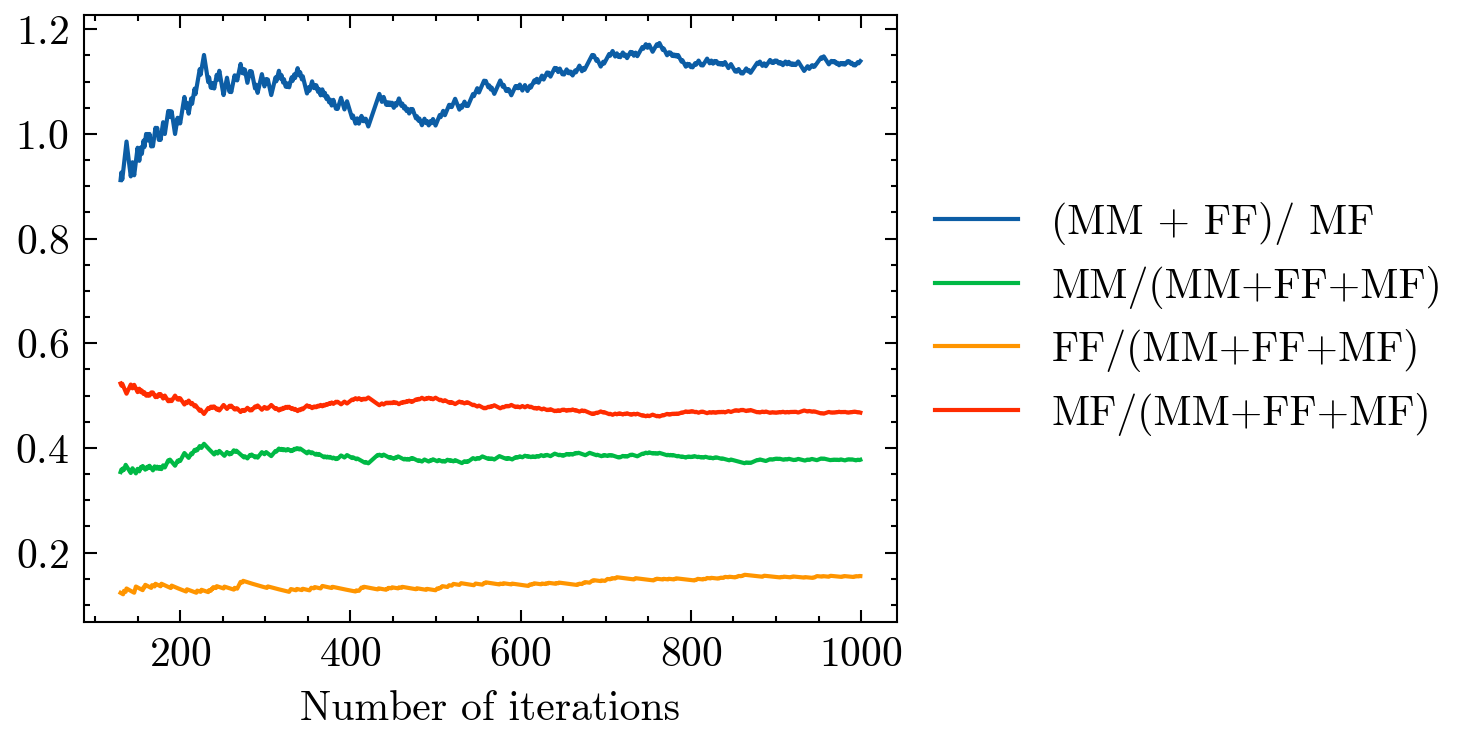

In [101]:
plt.figure(dpi=300)
plt.xlabel('Number of iterations');
# plt.ylabel('True Positive Disparity Ratio');
plt.plot(range(130, 1000), bias_ratio_overtime[100:], label='(MM + FF)/ MF');
plt.plot(range(130, 1000), mm[100:], label='MM/(MM+FF+MF)');
plt.plot(range(130, 1000), ff[100:], label='FF/(MM+FF+MF)');
plt.plot(range(130, 1000), mf[100:], label='MF/(MM+FF+MF)');

# plot dashed constant line
# plt.axhline(prob_mm, color='g', linestyle='--', label='MM');
# plt.axhline(prob_mf, color='r', linestyle='--', label='MF');
# plt.axhline(prob_ff, color='y', linestyle='--', label='FF');


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True);

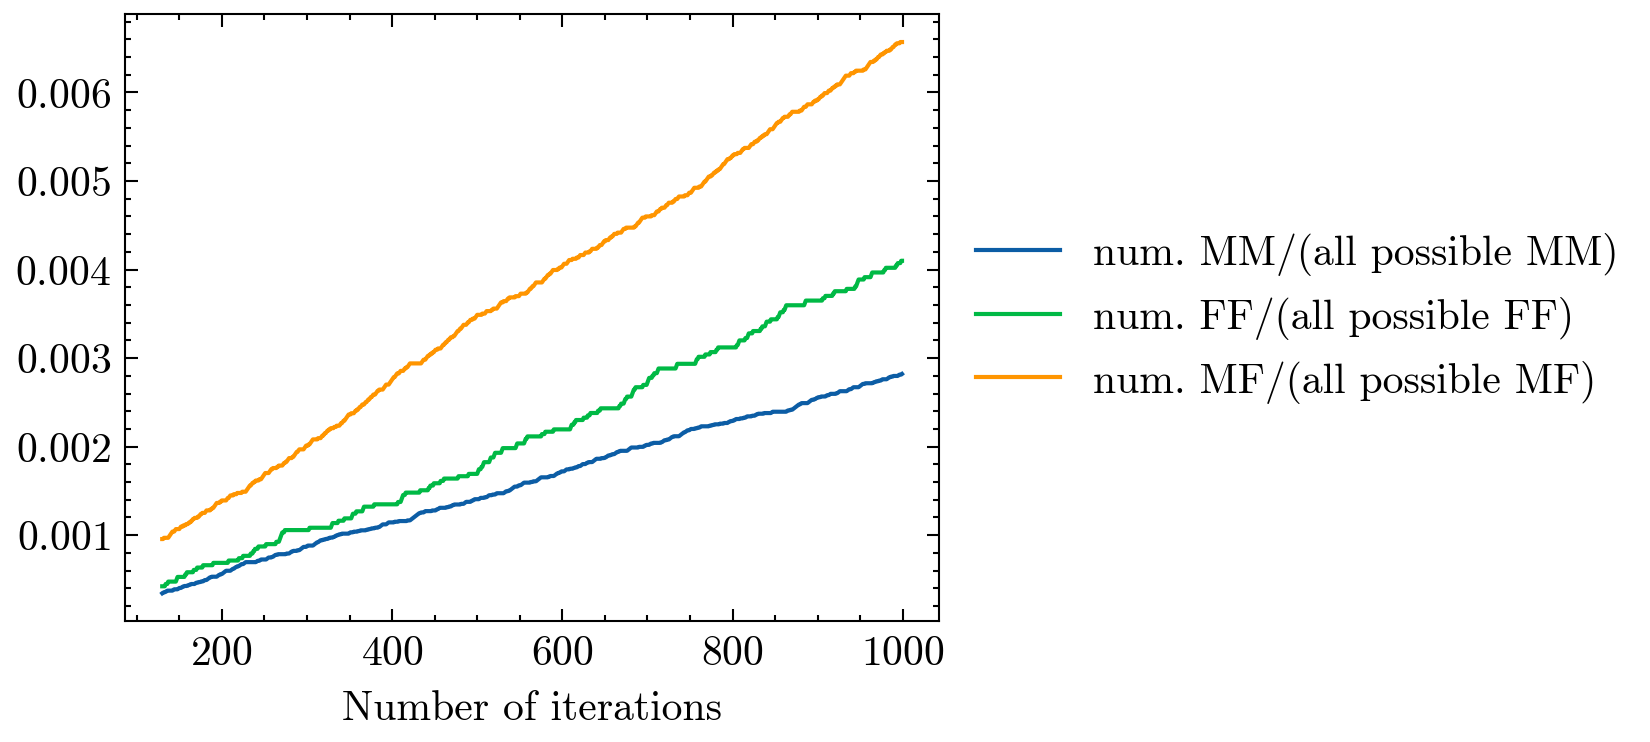

In [24]:
plt.figure(dpi=300)
plt.xlabel('Number of iterations');
# plt.ylabel('True Positive Disparity Ratio');
# plt.plot(range(130, 1000), bias_ratio_overtime[100:], label='(MM + FF)/ MF');
plt.plot(range(130, 1000), mm_norm[100:], label='num. MM/(all possible MM)');
plt.plot(range(130, 1000), ff_norm[100:], label='num. FF/(all possible FF)');
plt.plot(range(130, 1000), mf_norm[100:], label='num. MF/(all possible MF)');

# plot dashed constant line
# plt.axhline(prob_mm, color='g', linestyle='--', label='MM');
# plt.axhline(prob_mf, color='r', linestyle='--', label='MF');
# plt.axhline(prob_ff, color='y', linestyle='--', label='FF');


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True);

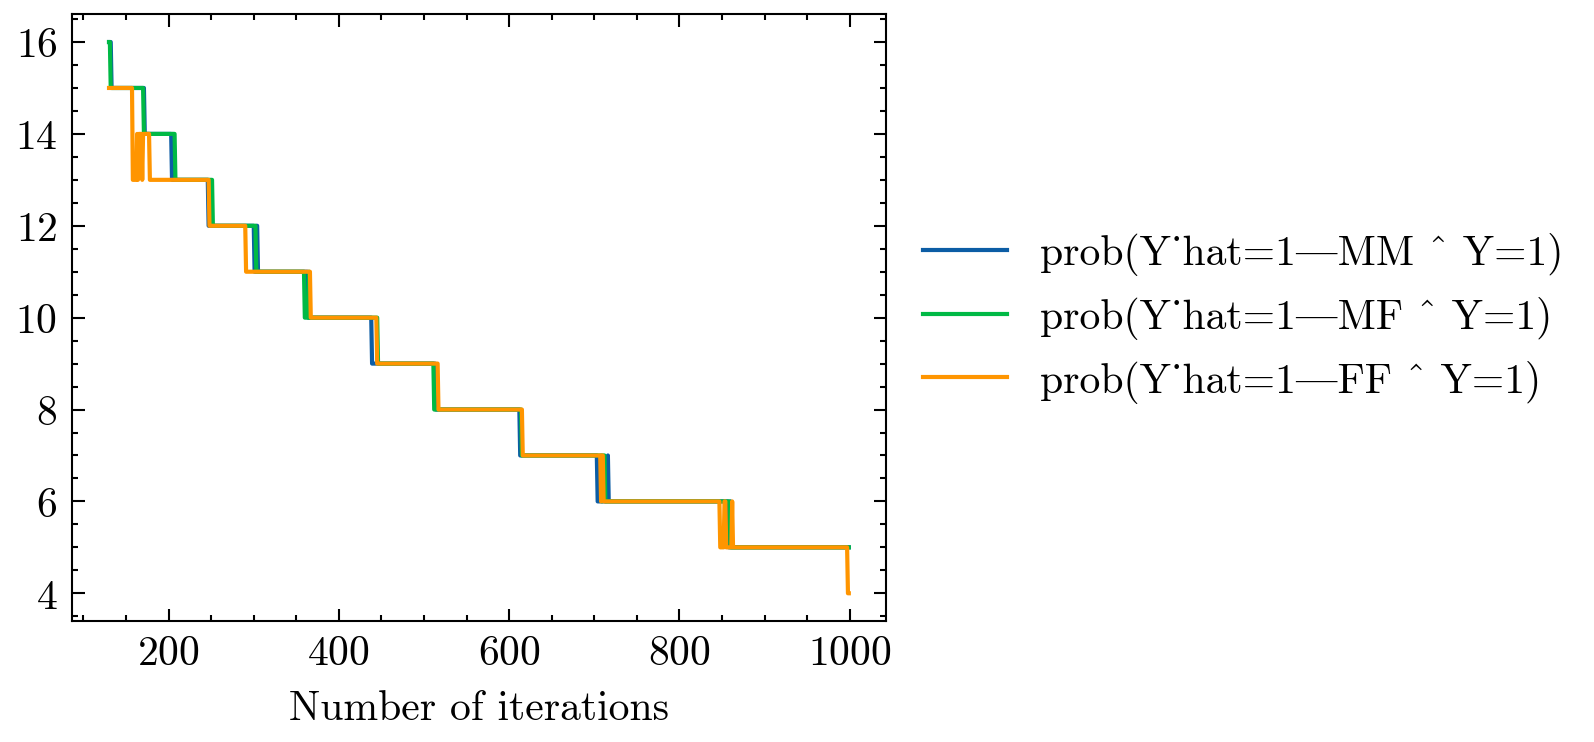

In [96]:
plt.figure(dpi=300)
plt.xlabel('Number of iterations');
# plt.ylabel('True Positive Disparity Ratio');
# plt.plot(range(130, 3000), bias_ratio_overtime[100:], label='(MM + FF)/ MF');
plt.plot(range(130, 1000), eq_op_mm[100:], label='prob(Y_hat=1|MM ^ Y=1)');
plt.plot(range(130, 1000), eq_op_mf[100:], label='prob(Y_hat=1|MF ^ Y=1)');
plt.plot(range(130, 1000), eq_op_ff[100:], label='prob(Y_hat=1|FF ^ Y=1)');


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True);

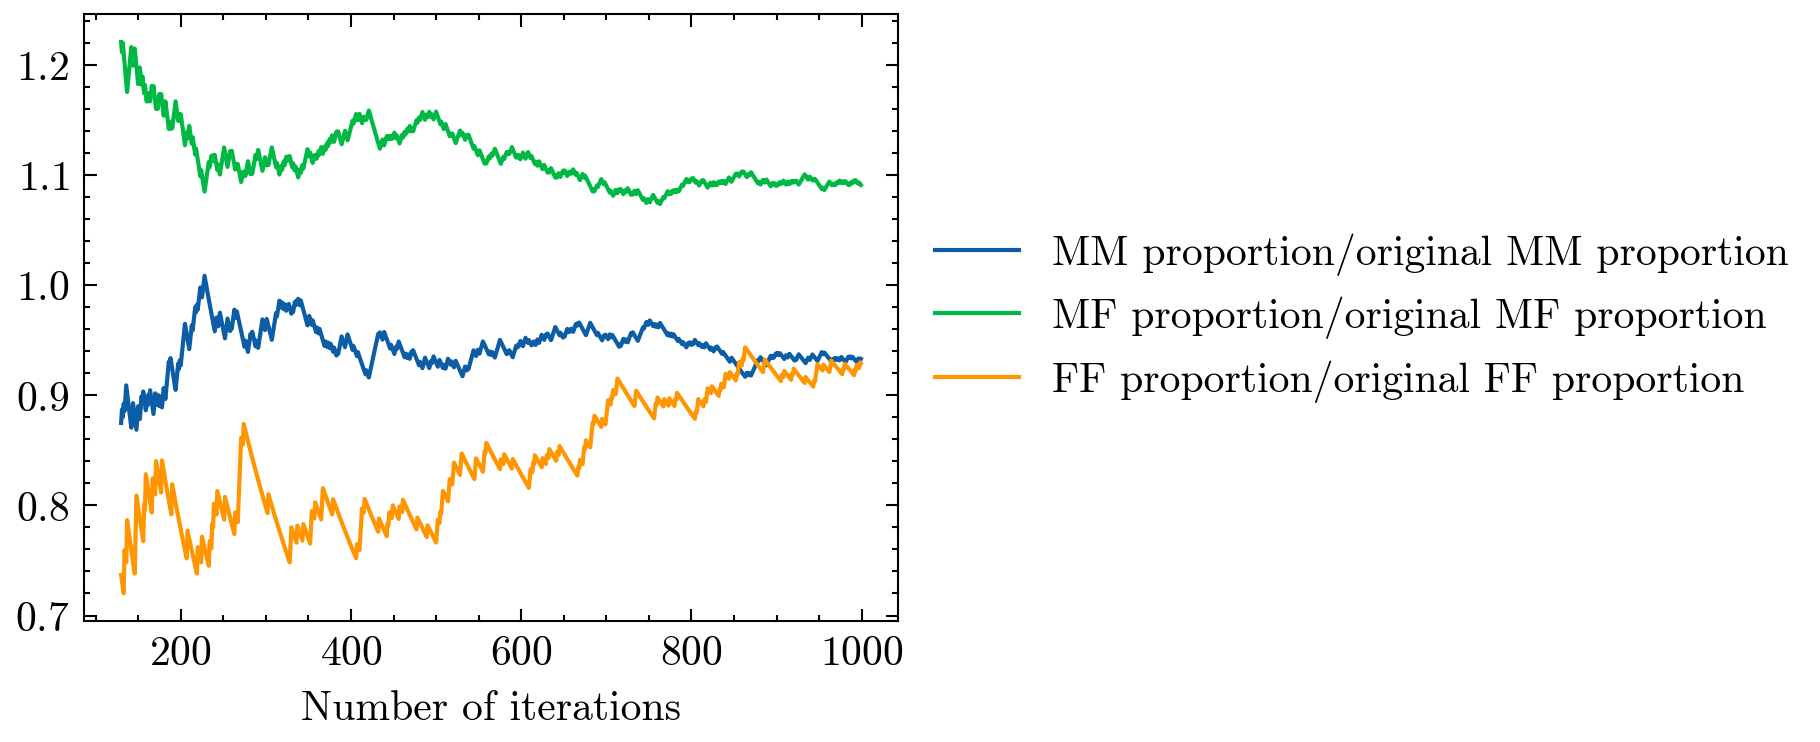

In [26]:
plt.figure(dpi=300)
plt.xlabel('Number of iterations');
# plt.ylabel('True Positive Disparity Ratio');
# plt.plot(range(130, 3000), bias_ratio_overtime[100:], label='(MM + FF)/ MF');
plt.plot(range(130, 1000), mm_prob_comparison[100:], label='MM proportion/original MM proportion');
plt.plot(range(130, 1000), mf_prob_comparison[100:], label='MF proportion/original MF proportion');
plt.plot(range(130, 1000), ff_prob_comparison[100:], label='FF proportion/original FF proportion');


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True);

## NBA

In [20]:
import sys

# sys.path.insert(1, '/home/jrm28/sparse_gelato/')


import torch
import torch_geometric
# from ogbdataset import get_dataset_from_gelato, load_dataset
from utils import adjoverlap
# from gelato_eval import *
from torch_sparse import SparseTensor
import datetime
from tqdm import tqdm
from math import ceil
import pandas as pd
from torch_geometric.datasets import Planetoid
import os
import matplotlib.pyplot as plt
import scienceplots

plt.style.use(['science', 'no-latex'])

dataset = 'nba'
data, splits = torch.load(f"/home/jrm28/fairness/NeuralCommonNeighbor/dataset/splits/{dataset}.pt")
splits['train']['edge'].shape

cur_edge_index = splits['train']['edge'].t()
cur_splits = splits['test']

# bias_measurements = []
pair_predicted_label = []
eq_op_mm_probs = []
eq_op_mf_probs = []
eq_op_ff_probs = []

for i in range(1000):

    adj = SparseTensor.from_edge_index(cur_edge_index, sparse_sizes=(splits['train']['edge'].max() + 1, splits['train']['edge'].max() + 1))
    # for batch_pos, batch_neg in tqdm(zip(compute_batches(splits['test']['edge'], ceil(0.1 * len(splits['test']['edge']))), compute_batches(splits['test']['edge_neg'], ceil(0.1 * len(splits['test']['edge_neg']))))):

    batch_pos = cur_splits['edge']
    batch_neg = cur_splits['edge_neg']

    common_neighbors_pos = adjoverlap(adj, adj, batch_pos.t(), False, False, cnsampledeg=-1)
    common_neighbors_neg = adjoverlap(adj, adj, batch_neg.t(), False, False, cnsampledeg=-1)

    now = datetime.datetime.now()

    timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
        
    labels, preds = concat_preds(cn_pos=[common_neighbors_pos.sum(1)], cn_neg=[common_neighbors_neg.sum(1)])
    norm_preds = (preds - preds.min())/(preds.max() - preds.min())


    # test_prec_at_100 = precision_at_k(labels, norm_preds, labels.int().sum().item())
    # test_ap = average_precision(eval_true=labels, eval_pred=norm_preds)
    # test_hits_at_50 = hits_at_k(labels, norm_preds, k=50)
    # test_hits_at_100 = hits_at_k(labels, norm_preds, k=100)
    # test_hits_at_1000 = hits_at_k(labels, norm_preds, k=1000)
    # test_mrr = mean_reciprocal_rank(labels, norm_preds)
    # test_auc = auc(labels.int(), norm_preds)

    # tprd = true_positive_rate_disparity(labels, norm_preds, data.y[torch.cat((cur_splits['edge'], cur_splits['edge_neg']))].sum(1)).abs()

    # gelato_results = {
    #         "test_precision_@_100%":test_prec_at_100,
    #         'test_ap': test_ap, 
    #         'test_hits_@_50': test_hits_at_50,
    #         'test_hits_@_100': test_hits_at_100,
    #         'test_hits_@_1000': test_hits_at_1000,
    #         'test_mrr': test_mrr,
    #         'test_auc': test_auc,
    #         'true_positive_rate_disparity': tprd}
    
    
    # Updating the splits to remove the top k pairs predicted from the test set
    values, indices = norm_preds.topk(1)
    all_pairs = torch.cat((cur_splits['edge'], cur_splits['edge_neg']))
    
    pair_predicted_label.extend(list(data.y[all_pairs[indices]].sum(1)))
    
    mask = torch.ones(all_pairs.shape[0])
    mask[indices] = 0
    
    cur_edge_index = torch.hstack((cur_edge_index, all_pairs.t()[:, indices]))
    
    all_pairs = all_pairs[mask.bool()]
    labels = labels[mask.bool()]
    
    cur_splits['edge'] = all_pairs[labels == 1]
    cur_splits['edge_neg'] = all_pairs[labels == 0]
    
    print(" >>> remaining pairs ---- ", len(all_pairs), f"------- {preds.max() - preds.min()}")
    
    
    # Eq opportunity measurement
    eq_op_mm_probs.append(preds[:len(cur_splits['edge'])][data.y[cur_splits['edge']].sum(1) == 0].topk(1)[0])
    eq_op_mf_probs.append(preds[:len(cur_splits['edge'])][data.y[cur_splits['edge']].sum(1) == 1].topk(1)[0])
    eq_op_ff_probs.append(preds[:len(cur_splits['edge'])][data.y[cur_splits['edge']].sum(1) == 2].topk(1)[0])
    
    # bias_measurements.append(tprd)
    

# pd.DataFrame.from_dict({i: [gelato_results[i]] for i in gelato_results.keys()}).to_csv(f'{dataset}_cn_intracluster.csv', index=False)


#     print(gelato_results)

 >>> remaining pairs ----  4247 ------- 40.0
 >>> remaining pairs ----  4246 ------- 39.0
 >>> remaining pairs ----  4245 ------- 39.0
 >>> remaining pairs ----  4244 ------- 38.0
 >>> remaining pairs ----  4243 ------- 38.0
 >>> remaining pairs ----  4242 ------- 32.0
 >>> remaining pairs ----  4241 ------- 31.0
 >>> remaining pairs ----  4240 ------- 30.0
 >>> remaining pairs ----  4239 ------- 30.0
 >>> remaining pairs ----  4238 ------- 29.0
 >>> remaining pairs ----  4237 ------- 29.0
 >>> remaining pairs ----  4236 ------- 28.0
 >>> remaining pairs ----  4235 ------- 27.0
 >>> remaining pairs ----  4234 ------- 27.0
 >>> remaining pairs ----  4233 ------- 26.0
 >>> remaining pairs ----  4232 ------- 25.0
 >>> remaining pairs ----  4231 ------- 24.0
 >>> remaining pairs ----  4230 ------- 24.0
 >>> remaining pairs ----  4229 ------- 23.0
 >>> remaining pairs ----  4228 ------- 23.0
 >>> remaining pairs ----  4227 ------- 23.0
 >>> remaining pairs ----  4226 ------- 23.0
 >>> remai

In [21]:
# prob_mm = (data.y[splits['train']['edge']].sum(1) == 0).sum() / (((data.y == 0).sum() ** 2) * 0.5)
# prob_ff = (data.y[splits['train']['edge']].sum(1) == 2).sum() / (((data.y == 1).sum() ** 2) * 0.5)
# prob_mf = (data.y[splits['train']['edge']].sum(1) == 1).sum() / (((data.y == 0).sum() * (data.y == 1).sum()) * 0.5)

prob_mm = (data.y[splits['train']['edge']].sum(1) == 0).sum() / splits['train']['edge'].shape[0]
prob_ff = (data.y[splits['train']['edge']].sum(1) == 2).sum() / splits['train']['edge'].shape[0]
prob_mf = (data.y[splits['train']['edge']].sum(1) == 1).sum() / splits['train']['edge'].shape[0]


bias_ratio_overtime = []
mm, ff, mf, = [], [], []
mm_prob_comparison, ff_prob_comparison, mf_prob_comparison, = [], [], []
mm_norm, ff_norm, mf_norm, = [], [], []
eq_op_mm, eq_op_mf, eq_op_ff = [], [], []
for i in range(30, 1000):
    timelapse = pair_predicted_label[:i]
    bias_ratio_overtime.append(((torch.tensor(timelapse) == 0).sum() + (torch.tensor(timelapse) == 2).sum()) / (torch.tensor(timelapse) == 1).sum().item())
    mm.append((torch.tensor(timelapse) == 0).sum()/len(timelapse))
    ff.append((torch.tensor(timelapse) == 2).sum()/len(timelapse))
    mf.append((torch.tensor(timelapse) == 1).sum()/len(timelapse))
    
    mm_norm.append((torch.tensor(timelapse) == 0).sum()/(((data.y == 0).sum() ** 2) * 0.5))
    ff_norm.append((torch.tensor(timelapse) == 2).sum()/(((data.y == 1).sum() ** 2) * 0.5))
    mf_norm.append((torch.tensor(timelapse) == 1).sum()/(((data.y == 0).sum() * (data.y == 1).sum()) * 0.5))
    
    # Prob Comparison
    mm_prob_comparison.append((torch.tensor(timelapse) == 0).sum()/(prob_mm * len(timelapse)))
    ff_prob_comparison.append((torch.tensor(timelapse) == 2).sum()/(prob_ff * len(timelapse)))
    mf_prob_comparison.append((torch.tensor(timelapse) == 1).sum()/(prob_mf * len(timelapse)))
    
    print((torch.tensor(timelapse) == 0).sum(), (prob_mm * len(timelapse)))
    
    # Eq. of opportunity comparison
    eq_op_mm.append(eq_op_mm_probs[i].item())
    eq_op_mf.append(eq_op_mf_probs[i].item())
    eq_op_ff.append(eq_op_ff_probs[i].item())

tensor(29) tensor(18.9119)
tensor(30) tensor(19.5423)
tensor(31) tensor(20.1727)
tensor(32) tensor(20.8031)
tensor(33) tensor(21.4335)
tensor(34) tensor(22.0639)
tensor(35) tensor(22.6943)
tensor(35) tensor(23.3247)
tensor(36) tensor(23.9551)
tensor(37) tensor(24.5855)
tensor(37) tensor(25.2159)
tensor(38) tensor(25.8463)
tensor(39) tensor(26.4767)
tensor(40) tensor(27.1071)
tensor(40) tensor(27.7375)
tensor(41) tensor(28.3679)
tensor(42) tensor(28.9983)
tensor(43) tensor(29.6286)
tensor(43) tensor(30.2590)
tensor(43) tensor(30.8894)
tensor(44) tensor(31.5198)
tensor(45) tensor(32.1502)
tensor(46) tensor(32.7806)
tensor(46) tensor(33.4110)
tensor(47) tensor(34.0414)
tensor(48) tensor(34.6718)
tensor(49) tensor(35.3022)
tensor(50) tensor(35.9326)
tensor(51) tensor(36.5630)
tensor(52) tensor(37.1934)
tensor(53) tensor(37.8238)
tensor(53) tensor(38.4542)
tensor(53) tensor(39.0846)
tensor(54) tensor(39.7150)
tensor(55) tensor(40.3454)
tensor(55) tensor(40.9758)
tensor(55) tensor(41.6062)
t

In [19]:
mm[-1], mf[-1], ff[-1], len(timelapse)

(tensor(0.6897), tensor(0.2523), tensor(0.0581), 999)

In [4]:

prob_mm, prob_mf, prob_ff = prob_mm.item(), prob_mf.item(), prob_ff.item()

prob_mm * len(timelapse), prob_mf * len(timelapse), prob_ff * len(timelapse)

(629.7663865685463, 278.8063123226166, 90.42730110883713)

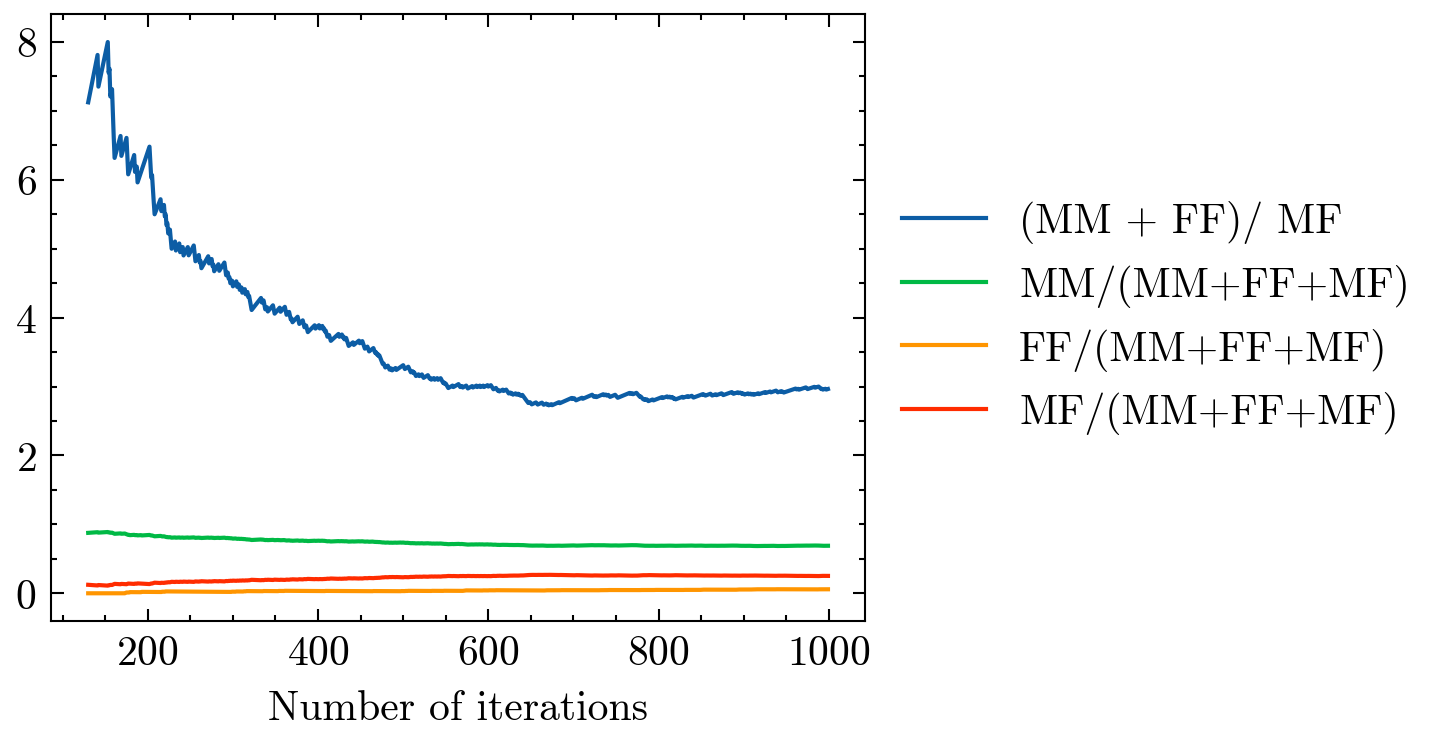

In [5]:
plt.figure(dpi=300)
plt.xlabel('Number of iterations');
# plt.ylabel('True Positive Disparity Ratio');
plt.plot(range(130, 1000), bias_ratio_overtime[100:], label='(MM + FF)/ MF');
plt.plot(range(130, 1000), mm[100:], label='MM/(MM+FF+MF)');
plt.plot(range(130, 1000), ff[100:], label='FF/(MM+FF+MF)');
plt.plot(range(130, 1000), mf[100:], label='MF/(MM+FF+MF)');

# plot dashed constant line
# plt.axhline(prob_mm, color='g', linestyle='--', label='MM');
# plt.axhline(prob_mf, color='r', linestyle='--', label='MF');
# plt.axhline(prob_ff, color='y', linestyle='--', label='FF');


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True);

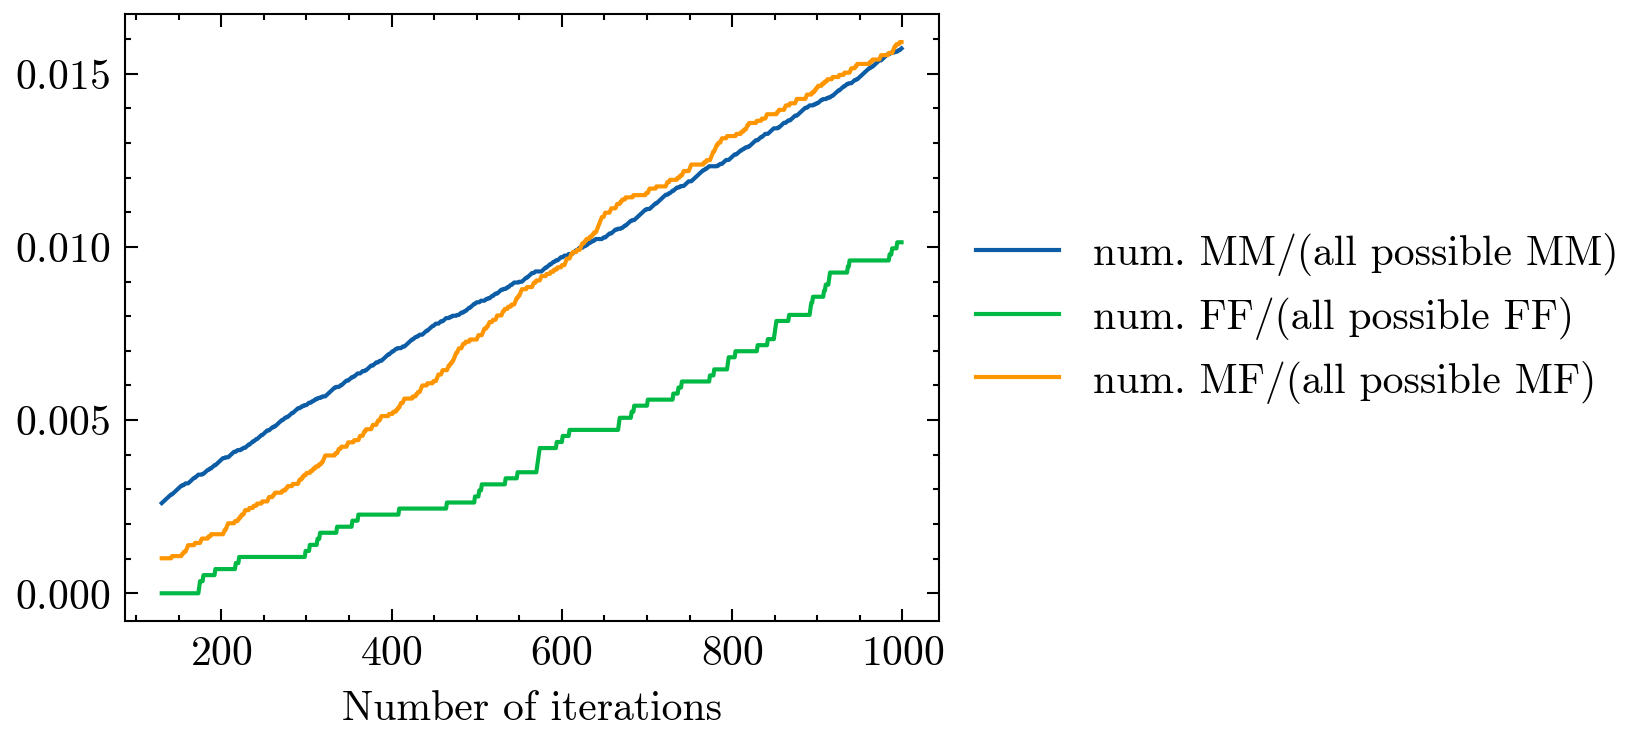

In [6]:
plt.figure(dpi=300)
plt.xlabel('Number of iterations');
# plt.ylabel('True Positive Disparity Ratio');
# plt.plot(range(130, 1000), bias_ratio_overtime[100:], label='(MM + FF)/ MF');
plt.plot(range(130, 1000), mm_norm[100:], label='num. MM/(all possible MM)');
plt.plot(range(130, 1000), ff_norm[100:], label='num. FF/(all possible FF)');
plt.plot(range(130, 1000), mf_norm[100:], label='num. MF/(all possible MF)');

# plot dashed constant line
# plt.axhline(prob_mm, color='g', linestyle='--', label='MM');
# plt.axhline(prob_mf, color='r', linestyle='--', label='MF');
# plt.axhline(prob_ff, color='y', linestyle='--', label='FF');


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True);

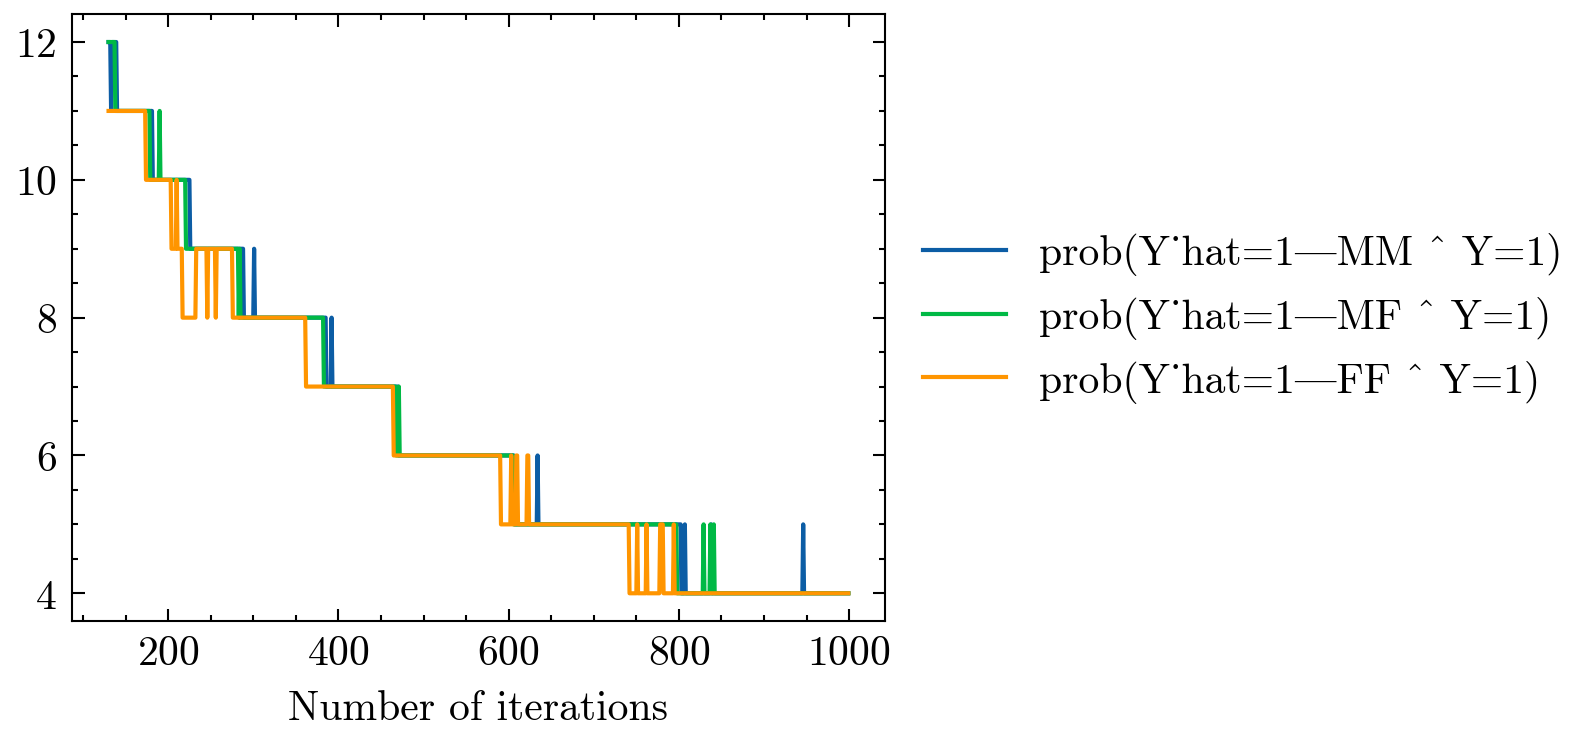

In [7]:
plt.figure(dpi=300)
plt.xlabel('Number of iterations');
# plt.ylabel('True Positive Disparity Ratio');
# plt.plot(range(130, 3000), bias_ratio_overtime[100:], label='(MM + FF)/ MF');
plt.plot(range(130, 1000), eq_op_mm[100:], label='prob(Y_hat=1|MM ^ Y=1)');
plt.plot(range(130, 1000), eq_op_mf[100:], label='prob(Y_hat=1|MF ^ Y=1)');
plt.plot(range(130, 1000), eq_op_ff[100:], label='prob(Y_hat=1|FF ^ Y=1)');


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True);

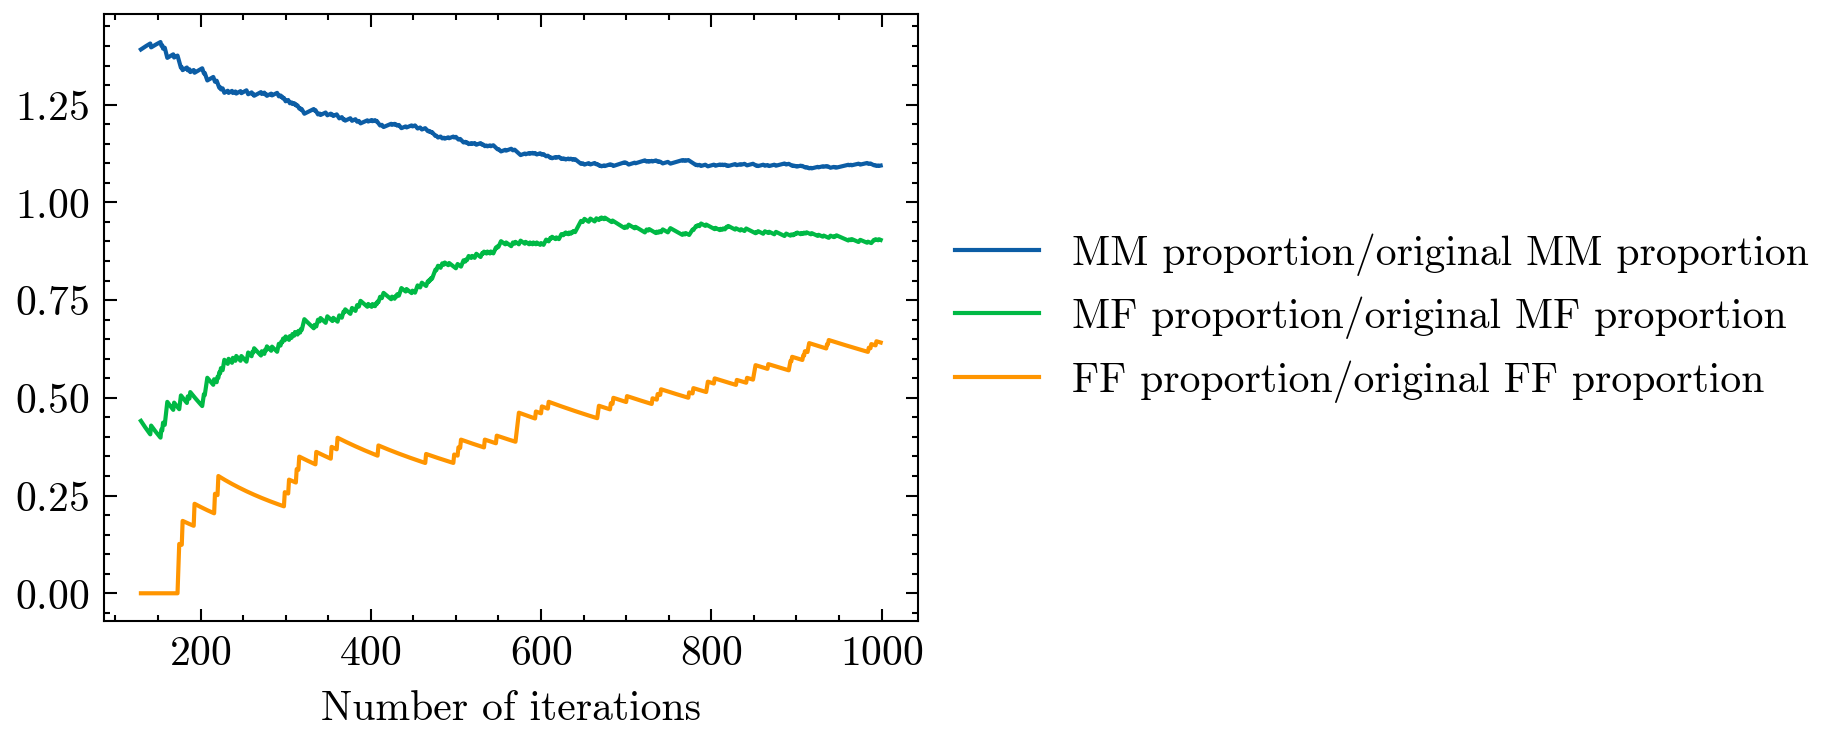

In [8]:
plt.figure(dpi=300)
plt.xlabel('Number of iterations');
# plt.ylabel('True Positive Disparity Ratio');
# plt.plot(range(130, 3000), bias_ratio_overtime[100:], label='(MM + FF)/ MF');
plt.plot(range(130, 1000), mm_prob_comparison[100:], label='MM proportion/original MM proportion');
plt.plot(range(130, 1000), mf_prob_comparison[100:], label='MF proportion/original MF proportion');
plt.plot(range(130, 1000), ff_prob_comparison[100:], label='FF proportion/original FF proportion');


plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True);